In [2]:
import pandas as pd
import numpy as np
import gzip
from Bio import SeqIO

# The datasets we are working with:
- Delrosso dataset
- Tycko dataset
- Soto dataset

In [3]:
Soto_domain_list1 = pd.read_excel('domain_list1_Soto.xlsx')
tycko_list = pd.read_csv('tycko_list_with_protein_sequences.csv')
soto_list = Soto_domain_list1[Soto_domain_list1['Domain type']=='RD'][['Uniprot ID', 'Coordinates', 'Sequence']]
soto_list[['Start', 'End']] = soto_list['Coordinates'].str.split('-', expand=True)
soto_list.drop('Coordinates', axis = 1, inplace = True)
delrosso_list = pd.read_excel('repression_domain_list_DelRosso.xlsx')[['UniProt ID', 'Start', 'End', 'Sequence']]
delrosso_list.rename(columns={'UniProt ID': 'Uniprot ID'}, inplace=True)
tycko_list.rename(columns={'UniProt ID': 'Uniprot ID'}, inplace=True)

In [4]:
tycko_list

,Sequence,Uniprot ID,Start,End
0,RFATRGYPMEDMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGA...,A9YTQ3,520,600
1,DMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVW...,A9YTQ3,530,610
2,PGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPA...,A9YTQ3,540,620
3,LDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPATFPTRMHLKT...,A9YTQ3,550,630
4,MDSLEEPQKKVFKARKTMRVSDRQQLEAVYKVKEELLKTDVKLLNG...,Q6VMQ6,0,80
...,...,...,...,...
380,MRVNHTVSTMLPTCMVHRQTMSCSGAGGITAFVAFRDVAVYFTQEE...,P10072,0,80
381,MSCSGAGGITAFVAFRDVAVYFTQEEWRLLSPAQRTLHREVMLETY...,P10072,20,100
382,AFVAFRDVAVYFTQEEWRLLSPAQRTLHREVMLETYNHLVSLEIPS...,P10072,30,110
383,HSGLKPYVCKECGQSFSLKSNLITHQRAHTGEKPYVCRECGRGFRQ...,P10072,350,430


In [5]:
soto_list

,Uniprot ID,Sequence,Start,End
0,Q6ZN18,AICFNLSAHIESLGKGHSVVFHSTVIAKRKEDSGKIKLLLHWMPED...,410,494
1,Q8WYP5,QEMDEGSQSLEKLDVSKGNSSVSITSDETTLEYQDAPSPEDLEETV...,1289,1444
3,Q8WYP5,DRDPRLRERSLARNSILDQYGKILPRVHRKLAIERAKPYHLSTSSV...,981,1146
16,Q96QS3,MSNQYQEEGCSERPECKSKSPTLLSSYCIDSILGRRSPCKMRLLGA...,1,66
17,Q96QS3,FPGPLSATHPLSPYLDASPFPPHHPALDSAWTAAAAAAAAAFPSLP...,400,495
...,...,...,...,...
917,P17098,DEGVAGVMSVGPPAARLQEPVTFRDVAVDFTQEEWGQLDPTQRILY...,5,116
918,Q0VGE8,MLREEATKKSKEKEPGMALPQGRLTFRDVAIEFSLEEWKCLNPAQR...,1,118
919,Q03923,MGPLTFRDVAIEFSLKEWQCLDTAQRNLYRNVMLENYRNLVFLGIT...,1,77
920,A6NK75,MLENYRNLVFVGIAASKPDLITCLEQGKEPWNVKRHEMVTEPPVVY...,42,145


In [6]:
delrosso_list

,Uniprot ID,Start,End,Sequence
0,Q9NQ94,311,410,RYTRGTGGRGTMLQGEYTYSLGQVYDPTTTYLGAPVFYAPQTYAAI...
1,Q6UWZ7,11,90,SGFVLGALAFQHLNTDSDTEGFLLGEVKGEAKNSITDSQMDDVEVV...
2,Q6UWZ7,181,260,TVSGSCMSTGFSRAVQTHSSKFFEEDGSLKEVHKINEMYASLQEEL...
3,Q15018,201,280,GVMKDIRAIYQVYNALQEKVQAVCADVEKSERVVESCQAEVNKLRR...
4,P10070,161,240,KPYKCQQPKKAFRYHPSFRTQERNHTGEKPYACKECGKTFISHSGI...
...,...,...,...,...
3895,A6NGD5,81,200,QILDMLVMEQFMISMPQELQVLVMMNGVQSCKDLEDLLRNNRRPKK...
3896,O15535,21,120,LLTMKVEAKSHLQWQESRLKRSNPLAREIFRRHFRQLCYQETPGPR...
3897,P10070,271,350,SGGYKQQQLRNMEIEVNRGRMPPSEFHRRKADMMESLALGFDDGKT...
3898,Q2QGD7,591,730,QQGSFSVDDVQTVSAGALGCLVALPMKNLSDDPLALTSNSNLAAHI...


### These are the relative sizes of each dataset:
- tycko = 385 rows
- soto = 389 rows
- delrosso = 3900 rows

# Now lets get all the unique Uniprot IDs from each datset

In [7]:
tycko_uniprots  = tycko_list['Uniprot ID'].drop_duplicates().to_list()
soto_uniprots  = soto_list['Uniprot ID'].drop_duplicates().to_list()
delrosso_uniprots  = delrosso_list['Uniprot ID'].drop_duplicates().to_list()

In [8]:
all_uniprot_IDs = pd.Series(tycko_uniprots + soto_uniprots + delrosso_uniprots)
all_uniprot_IDs =  all_uniprot_IDs.drop_duplicates()

In [ ]:
# This line saves all Uniprot IDs to Savio folder
all_uniprot_IDs.to_csv('all_uniprot_IDs.csv', header = None, index = None)

In [ ]:
# Next, upload all_uniprot_IDs.csv to the uniprot website's list search feature
# Click download button, and save fasta file of all isoforms and canonical sequences of search results

All our uniprot IDs are listed in all_uniprot_IDs.csv

# Now, lets get all the isoforms and canonical sequences using uniprot ID mapping

### 1. Make a isoform dictionary

In [ ]:
isoform_dict = {}

# Change path below to file you've downloaded from Uniprot
with gzip.open("all_isoforms_and_canonicals.fasta.gz", "rt") as fasta_file:
    for record in SeqIO.parse(fasta_file, "fasta"):
        full_id = record.id.split("|")[-2]  # Extract the full ID (e.g., UniprotID-1)
        isoform_dict[full_id] = str(record.seq)

# Print the number of parsed isoform entries
print(f"Parsed {len(isoform_dict)} isoform entries.")

Parsed 4025 isoform entries.


### 2. Create a function that parses through the dictionary and aligns sequences

In [ ]:
def find_isoform_coordinates(row):
    uniprot_id = row['Uniprot ID']
    sequence = row['Sequence']
    
    matching_isoforms = []
    new_start, new_end = None, None
    
    # Iterate through all isoforms for this Uniprot ID

    ## Modify this code so that you save a start and end per isoform, instead of per Uniprot ID

    for isoform, isoform_seq in isoform_dict.items():
        if isoform.startswith(uniprot_id) and sequence in isoform_seq:
            matching_isoforms.append(isoform)
            start_idx = isoform_seq.index(sequence) + 1  # 1-based indexing
            end_idx = start_idx + len(sequence) - 1
            new_start, new_end = start_idx, end_idx
    
    return pd.Series({
        'isoforms': ', '.join(matching_isoforms),
        'new_start': new_start,
        'new_end': new_end
    })

### 3. Apply the function to each of the datasets

In [12]:
tycko_list[['isoforms', 'new_start', 'new_end']] = tycko_list.apply(find_isoform_coordinates, axis=1)
soto_list[['isoforms', 'new_start', 'new_end']] = soto_list.apply(find_isoform_coordinates, axis=1)
delrosso_list[['isoforms', 'new_start', 'new_end']] = delrosso_list.apply(find_isoform_coordinates, axis=1)

In [13]:
tycko_list

,Sequence,Uniprot ID,Start,End,isoforms,new_start,new_end
0,RFATRGYPMEDMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGA...,A9YTQ3,520,600,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",517.0,596.0
1,DMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVW...,A9YTQ3,530,610,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",527.0,606.0
2,PGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPA...,A9YTQ3,540,620,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",537.0,616.0
3,LDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPATFPTRMHLKT...,A9YTQ3,550,630,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",547.0,626.0
4,MDSLEEPQKKVFKARKTMRVSDRQQLEAVYKVKEELLKTDVKLLNG...,Q6VMQ6,0,80,"Q6VMQ6, Q6VMQ6-2, Q6VMQ6-4, Q6VMQ6-5",1.0,80.0
...,...,...,...,...,...,...,...
380,MRVNHTVSTMLPTCMVHRQTMSCSGAGGITAFVAFRDVAVYFTQEE...,P10072,0,80,P10072,1.0,80.0
381,MSCSGAGGITAFVAFRDVAVYFTQEEWRLLSPAQRTLHREVMLETY...,P10072,20,100,P10072,21.0,100.0
382,AFVAFRDVAVYFTQEEWRLLSPAQRTLHREVMLETYNHLVSLEIPS...,P10072,30,110,"P10072, P10072-2",12.0,91.0
383,HSGLKPYVCKECGQSFSLKSNLITHQRAHTGEKPYVCRECGRGFRQ...,P10072,350,430,"P10072, P10072-2",332.0,411.0


In [14]:
soto_list

,Uniprot ID,Sequence,Start,End,isoforms,new_start,new_end
0,Q6ZN18,AICFNLSAHIESLGKGHSVVFHSTVIAKRKEDSGKIKLLLHWMPED...,410,494,"Q6ZN18, Q6ZN18-2, Q6ZN18-3",194,278
1,Q8WYP5,QEMDEGSQSLEKLDVSKGNSSVSITSDETTLEYQDAPSPEDLEETV...,1289,1444,"Q8WYP5, Q8WYP5-2, Q8WYP5-3",1298,1453
3,Q8WYP5,DRDPRLRERSLARNSILDQYGKILPRVHRKLAIERAKPYHLSTSSV...,981,1146,"Q8WYP5, Q8WYP5-2, Q8WYP5-3",990,1155
16,Q96QS3,MSNQYQEEGCSERPECKSKSPTLLSSYCIDSILGRRSPCKMRLLGA...,1,66,Q96QS3,1,66
17,Q96QS3,FPGPLSATHPLSPYLDASPFPPHHPALDSAWTAAAAAAAAAFPSLP...,400,495,Q96QS3,400,495
...,...,...,...,...,...,...,...
917,P17098,DEGVAGVMSVGPPAARLQEPVTFRDVAVDFTQEEWGQLDPTQRILY...,5,116,P17098,5,116
918,Q0VGE8,MLREEATKKSKEKEPGMALPQGRLTFRDVAIEFSLEEWKCLNPAQR...,1,118,Q0VGE8,1,118
919,Q03923,MGPLTFRDVAIEFSLKEWQCLDTAQRNLYRNVMLENYRNLVFLGIT...,1,77,Q03923,1,77
920,A6NK75,MLENYRNLVFVGIAASKPDLITCLEQGKEPWNVKRHEMVTEPPVVY...,42,145,A6NK75,42,145


In [15]:
delrosso_list

,Uniprot ID,Start,End,Sequence,isoforms,new_start,new_end
0,Q9NQ94,311,410,RYTRGTGGRGTMLQGEYTYSLGQVYDPTTTYLGAPVFYAPQTYAAI...,"Q9NQ94, Q9NQ94-5, Q9NQ94-6",256.0,355.0
1,Q6UWZ7,11,90,SGFVLGALAFQHLNTDSDTEGFLLGEVKGEAKNSITDSQMDDVEVV...,Q6UWZ7,11.0,90.0
2,Q6UWZ7,181,260,TVSGSCMSTGFSRAVQTHSSKFFEEDGSLKEVHKINEMYASLQEEL...,"Q6UWZ7, Q6UWZ7-2",72.0,151.0
3,Q15018,201,280,GVMKDIRAIYQVYNALQEKVQAVCADVEKSERVVESCQAEVNKLRR...,Q15018,201.0,280.0
4,P10070,161,240,KPYKCQQPKKAFRYHPSFRTQERNHTGEKPYACKECGKTFISHSGI...,,NaN,NaN
...,...,...,...,...,...,...,...
3895,A6NGD5,81,200,QILDMLVMEQFMISMPQELQVLVMMNGVQSCKDLEDLLRNNRRPKK...,A6NGD5,82.0,201.0
3896,O15535,21,120,LLTMKVEAKSHLQWQESRLKRSNPLAREIFRRHFRQLCYQETPGPR...,"O15535, O15535-2",22.0,121.0
3897,P10070,271,350,SGGYKQQQLRNMEIEVNRGRMPPSEFHRRKADMMESLALGFDDGKT...,,NaN,NaN
3898,Q2QGD7,591,730,QQGSFSVDDVQTVSAGALGCLVALPMKNLSDDPLALTSNSNLAAHI...,Q2QGD7,592.0,731.0


## We can conclude that:
- Most sequences are subsequences of canonicals and isoforms
- There are some sequences that are not a subsequence of any isoform or canonical sequence (shown below)

In [16]:
print('There are', len(tycko_list[tycko_list['isoforms'] == '']), 'sequences that are not a subsequence of the canonical or any isoforms.')
print('There are', len(soto_list[soto_list['isoforms'] == '']), 'sequences that are not a subsequence of the canonical or any isoforms.')
print('There are', len(delrosso_list[delrosso_list['isoforms'] == '']), 'sequences that are not a subsequence of the canonical or any isoforms.')

There are 12 sequences that are not a subsequence of the canonical or any isoforms.
There are 0 sequences that are not a subsequence of the canonical or any isoforms.
There are 142 sequences that are not a subsequence of the canonical or any isoforms.


### Let's drop all of these rows:

In [17]:
tycko_list = tycko_list[tycko_list['isoforms'] != ''].drop(columns = ['Start', 'End'])
tycko_list.rename(columns={'new_start': 'start', 'new_end': 'end'}, inplace=True)
soto_list = soto_list[soto_list['isoforms'] != ''].drop(columns = ['Start', 'End'])
soto_list.rename(columns={'new_start': 'start', 'new_end': 'end'}, inplace=True)
delrosso_list = delrosso_list[delrosso_list['isoforms'] != ''].drop(columns = ['Start', 'End'])
delrosso_list.rename(columns={'new_start': 'start', 'new_end': 'end'}, inplace=True)

### How big is each dataset now?


In [18]:
print('Tycko dataset is', len(tycko_list))
print('Soto dataset is', len(soto_list))
print('Delrosso dataset is', len(delrosso_list))

Tycko dataset is 373
Soto dataset is 389
Delrosso dataset is 3758


# Before we start merging, let's make sure that we create new rows for sequences that are only subsequences of isoforms:
- Why? Because when we merge and combine overlaps later on, we want to make sure that we are not combining the isoforms with canonicals because it will result in incorrect sequences downstream.

 ### Let's create a function that updates the uniprot ID with the isoform ID

In [19]:
def update_uniprot_id(row):
    isoforms = row['isoforms'].split(', ')
    first_isoform = isoforms[0]
    if '-' in first_isoform:  
        return first_isoform
    return row['Uniprot ID']

### Apply this funtion to all of our lists

In [20]:
tycko_list['Uniprot ID'] = tycko_list.apply(update_uniprot_id, axis=1)
soto_list['Uniprot ID'] = soto_list.apply(update_uniprot_id, axis=1)
delrosso_list['Uniprot ID'] = delrosso_list.apply(update_uniprot_id, axis=1)

Now we have all uniprot IDs including isoforms and we aer ready to merge and combine

# Now lets do some merging and combine overlaps:
- First, do this with Soto and Tycko --> soto_tycko_list
- Second, do this with the soto_tycko_list and delrosso_list

### Let's merge the Soto and Tycko Lists

In [21]:
# Merge based on the UniProt ID
soto_tycko_merge = pd.merge(tycko_list, soto_list, how= 'outer', on='Uniprot ID', suffixes=('_tycko', '_soto'))
soto_tycko_merge

,Sequence_tycko,Uniprot ID,isoforms_tycko,start_tycko,end_tycko,Sequence_soto,isoforms_soto,start_soto,end_soto
0,RFATRGYPMEDMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGA...,A9YTQ3,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",517.0,596.0,NaN,NaN,NaN,NaN
1,DMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVW...,A9YTQ3,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",527.0,606.0,NaN,NaN,NaN,NaN
2,PGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPA...,A9YTQ3,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",537.0,616.0,NaN,NaN,NaN,NaN
3,LDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPATFPTRMHLKT...,A9YTQ3,"A9YTQ3, A9YTQ3-2, A9YTQ3-3",547.0,626.0,NaN,NaN,NaN,NaN
4,MDSLEEPQKKVFKARKTMRVSDRQQLEAVYKVKEELLKTDVKLLNG...,Q6VMQ6,"Q6VMQ6, Q6VMQ6-2, Q6VMQ6-4, Q6VMQ6-5",1.0,80.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
765,NaN,P17098,NaN,NaN,NaN,DEGVAGVMSVGPPAARLQEPVTFRDVAVDFTQEEWGQLDPTQRILY...,P17098,5.0,116.0
766,NaN,Q0VGE8,NaN,NaN,NaN,MLREEATKKSKEKEPGMALPQGRLTFRDVAIEFSLEEWKCLNPAQR...,Q0VGE8,1.0,118.0
767,NaN,Q03923,NaN,NaN,NaN,MGPLTFRDVAIEFSLKEWQCLDTAQRNLYRNVMLENYRNLVFLGIT...,Q03923,1.0,77.0
768,NaN,A6NK75,NaN,NaN,NaN,MLENYRNLVFVGIAASKPDLITCLEQGKEPWNVKRHEMVTEPPVVY...,A6NK75,42.0,145.0


There are rows that have merged together and rows that have not. For the rows that merged, if there is an overlap between those merges then we want to combine those sequences and coordinates. If there is no overlap, then we want to split those sequences into two rows.

# Now, create a function to combine overlaps and split rows where there are no overlaps:
- Make sure that we are combining the sequences on the overlap and not just concatenating the sequences together.

In [22]:
def combine_sequences_by_coordinates(seq_A, start_A, end_A, 
                                     seq_B, start_B, end_B):
    """
    Combine two sequences based on their coordinates.
    
    Parameters:
        seq_A, start_A, end_A: Sequence and coordinates of the first source.
        seq_B, start_B, end_B: Sequence and coordinates of the second source.

    Returns:
        Combined sequence, combined start, and combined end.
    """
    # Find the global start and end
    combined_start = min(start_A, start_B)
    combined_end = max(end_A, end_B)

    # Build the combined sequence
    # Add the leftmost non-overlapping part of seq_B
    left_non_overlap = seq_B[:max(0, start_A - start_B)] if start_B < start_A else ''

    # Add the overlapping or main body of seq_A
    overlap_A = seq_A

    # Add the rightmost non-overlapping part of seq_B
    right_non_overlap = seq_B[(end_A - start_B + 1):] if end_A < end_B else ''

    # Concatenate all parts
    combined_sequence = left_non_overlap + overlap_A + right_non_overlap

    return combined_sequence, combined_start, combined_end

In [23]:
def create_individual_row(row, seq, start, end, source):
    """
    Create a new row with sequence details.
    """
    new_row = row.copy()
    new_row['Combined_Sequence'] = seq
    new_row['Combined_Start'] = start
    new_row['Combined_End'] = end
    new_row['Source'] = source
    return new_row



In [24]:
def combine_or_split_sequences_general(row, start_A_col, end_A_col, seq_A_col, 
                                       start_B_col, end_B_col, seq_B_col, A, B):
    """
    Combine or split sequences from two sources based on overlap or no overlap.
    """
    # Extract column values
    start_A = int(row[start_A_col]) if not pd.isna(row[start_A_col]) else None
    end_A = int(row[end_A_col]) if not pd.isna(row[end_A_col]) else None
    start_B = int(row[start_B_col]) if not pd.isna(row[start_B_col]) else None
    end_B = int(row[end_B_col]) if not pd.isna(row[end_B_col]) else None
    seq_A = row[seq_A_col]
    seq_B = row[seq_B_col]

    # Case 1: One of the sequences is missing
    if start_A is None or end_A is None:
        return [create_individual_row(row, seq_B, start_B, end_B, B)]

    if start_B is None or end_B is None:
        return [create_individual_row(row, seq_A, start_A, end_A, A)]

    # Calculate overlap
    start_max = max(start_A, start_B)
    end_min = min(end_A, end_B)

    # Case 2: Combine sequences if overlap exists
    if start_max <= end_min:
        combined_sequence, combined_start, combined_end = combine_sequences_by_coordinates(
            seq_A, start_A, end_A, seq_B, start_B, end_B
        )
        return [create_individual_row(row, combined_sequence, combined_start, combined_end, A + ', ' + B)]

    # Case 3: Split into two rows if no overlap
    A_row = create_individual_row(row, seq_A, start_A, end_A, A)
    B_row = create_individual_row(row, seq_B, start_B, end_B, B)
    return [A_row, B_row]


In [25]:
def process_table_general(dataframe, start_A_col, end_A_col, seq_A_col, 
                          start_B_col, end_B_col, seq_B_col, A, B):
    """
    Process the entire table to combine or split sequences row by row.
    """
    result = []
    for idx, row in dataframe.iterrows():
        result.extend(combine_or_split_sequences_general(
            row, start_A_col, end_A_col, seq_A_col, 
            start_B_col, end_B_col, seq_B_col, A, B
        ))
    return pd.DataFrame(result)

### Apply this function to the merged soto and tycko table

In [26]:
tycko_soto_combined = process_table_general(
    dataframe=soto_tycko_merge,
    start_A_col='start_tycko',
    end_A_col='end_tycko',
    seq_A_col='Sequence_tycko',
    start_B_col='start_soto',
    end_B_col='end_soto',
    seq_B_col='Sequence_soto',
    A = 'tycko',
    B = 'soto'
)

In [27]:
overlapped_data = tycko_soto_combined[tycko_soto_combined['Source'] == 'tycko, soto']#.loc[110][['Combined_Sequence', 'Combined_Start', 'Combined_End']]['Combined_Sequence']
#combined_data[~combined_data['Combined_Sequence'].isna()]
#len('APCKLGSQAGEAAKVFGGFQVVPAPDGQFAFLIPNGAFAHSGPVIPVYTSNSGTSVGPNAVSPSSGPSLTADSMWRPWRN')

### Lets verify that the sequences have been properly combined by checking the sequence lengths
- Create a function that verifies the lengths of the sequences where there is overlap and apply it to the combined data

In [28]:
def verify_combined_lengths(row, seq_A_col, seq_B_col, combined_seq_col, A, B):
    A_length = len(row[seq_A_col]) if pd.notna(row[seq_A_col]) else 0
    B_length = len(row[seq_B_col]) if pd.notna(row[seq_B_col]) else 0
    combined_length = len(row[combined_seq_col])
    
    # Calculate overlap length
    overlap_length = max(0, min(row['end_' + A], row['end_'+B]) - max(row['start_'+A], row['start_'+B]) + 1)
    
    # Expected combined length
    expected_length = A_length + B_length - overlap_length
    
    return combined_length == expected_length

In [29]:
tycko_soto_combined['is_length_correct'] = tycko_soto_combined.apply(
    verify_combined_lengths, axis=1,
    seq_A_col="Sequence_tycko", seq_B_col="Sequence_soto", combined_seq_col="Combined_Sequence", A='tycko', B='soto'
)

In [30]:
tycko_soto_combined = tycko_soto_combined.drop_duplicates()

In [31]:
overlapped_data

,Sequence_tycko,Uniprot ID,isoforms_tycko,start_tycko,end_tycko,Sequence_soto,isoforms_soto,start_soto,end_soto,Combined_Sequence,Combined_Start,Combined_End,Source
84,QQLFELTDDKENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLD...,O75461,"O75461, O75461-2, O75461-3",134.0,213.0,DDKENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLDVPAPRED...,"O75461, O75461-2, O75461-3",141.0,249.0,QQLFELTDDKENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLD...,134,249,"tycko, soto"
85,ENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLDVPAPREDSIT...,O75461,"O75461, O75461-2, O75461-3",144.0,223.0,DDKENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLDVPAPRED...,"O75461, O75461-2, O75461-3",141.0,249.0,DDKENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLDVPAPRED...,141,249,"tycko, soto"
86,QDIHSIQAFHEQIVIAVKAPAETRLDVPAPREDSITVHIRSTNGPI...,O75461,"O75461, O75461-2, O75461-3",154.0,233.0,DDKENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLDVPAPRED...,"O75461, O75461-2, O75461-3",141.0,249.0,DDKENERLAYVTYQDIHSIQAFHEQIVIAVKAPAETRLDVPAPRED...,141,249,"tycko, soto"
90,KSGGSAGGLAEGAGALAPPPPPPQIKVEPISEGESEEVEVTDISDE...,P50548,"P50548, P50548-2",326.0,405.0,PGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFEDEGEDKKVRGEG...,"P50548, P50548-2",397.0,455.0,KSGGSAGGLAEGAGALAPPPPPPQIKVEPISEGESEEVEVTDISDE...,326,455,"tycko, soto"
91,SEGESEEVEVTDISDEDEEDGEVFKTPRAPPAPPKPEPGEAPGASQ...,P50548,"P50548, P50548-2",356.0,435.0,PGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFEDEGEDKKVRGEG...,"P50548, P50548-2",397.0,455.0,SEGESEEVEVTDISDEDEEDGEVFKTPRAPPAPPKPEPGEAPGASQ...,356,455,"tycko, soto"
92,PAPPKPEPGEAPGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFED...,P50548,"P50548, P50548-2",386.0,465.0,PGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFEDEGEDKKVRGEG...,"P50548, P50548-2",397.0,455.0,PAPPKPEPGEAPGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFED...,386,465,"tycko, soto"
93,GEAPGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFEDEGEDKKVR...,P50548,"P50548, P50548-2",394.0,473.0,PGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFEDEGEDKKVRGEG...,"P50548, P50548-2",397.0,455.0,GEAPGASQCMPLKLRFKRRWSEDCRLEGGGGPAGGFEDEGEDKKVR...,394,473,"tycko, soto"
110,APCKLGSQAGEAAKVFGGFQVVPAPDGQFAFLIPNGAFAHSGPVIP...,Q14469,Q14469,201.0,280.0,WRPW,Q14469,275.0,278.0,APCKLGSQAGEAAKVFGGFQVVPAPDGQFAFLIPNGAFAHSGPVIP...,201,280,"tycko, soto"
112,GSTMDSAGLGQEAPALFRPCTPAVWAPAPAAGGPRSPPPLLLLPES...,Q5TGS1,Q5TGS1,101.0,180.0,WRPW,Q5TGS1,175.0,178.0,GSTMDSAGLGQEAPALFRPCTPAVWAPAPAAGGPRSPPPLLLLPES...,101,180,"tycko, soto"
114,DYSEGYSWCLQEAVQFLTLHAASDTQMKLLYHFQRPPAAPAAPAKE...,Q5TA89,Q5TA89,87.0,166.0,WRPW,Q5TA89,163.0,166.0,DYSEGYSWCLQEAVQFLTLHAASDTQMKLLYHFQRPPAAPAAPAKE...,87,166,"tycko, soto"


It looks like all the lengths match up! 

# Let's clean up our table and get rid of all the NaNs:

In [32]:
def combine_coordinates(data, Sequence_A_Col, Sequence_B_Col, Start_A_Col, End_A_Col, Start_B_Col, End_B_Col, Isoforms_A_Col, Isoforms_B_Col, A, B):
    # Create the 'sequence' unified column
    data['Sequence'] = data['Combined_Sequence'].fillna(
        data[Sequence_A_Col].fillna(data[Sequence_B_Col])
    )

    # Create the 'start' unified column
    data['start'] = data['Combined_Start'].fillna(
        data[Start_A_Col].fillna(data[Start_B_Col])
    )

    # Create the 'end' unified column
    data['end'] = data['Combined_End'].fillna(
        data[End_A_Col].fillna(data[End_B_Col])
    )

    # Handle missing isoforms
    data[Isoforms_A_Col] = data[Isoforms_A_Col].fillna('')
    data[Isoforms_B_Col] = data[Isoforms_B_Col].fillna('')

    # Merge isoforms, avoiding duplicates
    data['isoforms'] = data.apply(
        lambda row: ', '.join(
            set((row[Isoforms_A_Col] + ',' + row[Isoforms_B_Col]).split(', '))
        ).strip(', ') if row[Isoforms_A_Col] or row[Isoforms_B_Col] else '',
        axis=1
    )

    # Drop the old columns that have been merged
    columns_to_drop = [
        Sequence_A_Col, Start_A_Col,  End_A_Col,
        Sequence_B_Col, Start_B_Col, End_B_Col,
        'Combined_Sequence', 'Combined_Start', 'Combined_End',
        Isoforms_A_Col, Isoforms_B_Col
    ]
    data.drop(columns=columns_to_drop, inplace=True)

    return data

In [33]:
tycko_soto_list = combine_coordinates(tycko_soto_combined, 'Sequence_tycko', 'Sequence_soto', 'start_tycko', 'end_tycko', 'start_soto', 'end_soto', 'isoforms_tycko', 'isoforms_soto', 'tycko', 'soto')


In [34]:
tycko_soto_list

,Uniprot ID,Source,is_length_correct,Sequence,start,end,isoforms
0,A9YTQ3,tycko,False,RFATRGYPMEDMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGA...,517,596,"A9YTQ3-2, A9YTQ3-3,, A9YTQ3"
1,A9YTQ3,tycko,False,DMKLQGVPMPPGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVW...,527,606,"A9YTQ3-2, A9YTQ3-3,, A9YTQ3"
2,A9YTQ3,tycko,False,PGDLCGPTLLLDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPA...,537,616,"A9YTQ3-2, A9YTQ3-3,, A9YTQ3"
3,A9YTQ3,tycko,False,LDVSIKMEKDSGCEGAADGCVPSQVWLGASDRSHPATFPTRMHLKT...,547,626,"A9YTQ3-2, A9YTQ3-3,, A9YTQ3"
4,Q6VMQ6,tycko,False,MDSLEEPQKKVFKARKTMRVSDRQQLEAVYKVKEELLKTDVKLLNG...,1,80,"Q6VMQ6-4, Q6VMQ6, Q6VMQ6-2, Q6VMQ6-5"
...,...,...,...,...,...,...,...
765,P17098,soto,True,DEGVAGVMSVGPPAARLQEPVTFRDVAVDFTQEEWGQLDPTQRILY...,5,116,P17098
766,Q0VGE8,soto,True,MLREEATKKSKEKEPGMALPQGRLTFRDVAIEFSLEEWKCLNPAQR...,1,118,Q0VGE8
767,Q03923,soto,True,MGPLTFRDVAIEFSLKEWQCLDTAQRNLYRNVMLENYRNLVFLGIT...,1,77,Q03923
768,A6NK75,soto,True,MLENYRNLVFVGIAASKPDLITCLEQGKEPWNVKRHEMVTEPPVVY...,42,145,A6NK75


# Now let's combine overlap within the same dataframe:

In [35]:
def combine_sequences_within_dataframe(df, id_col, start_col, end_col, seq_col, source_col, isoforms_col):

    df = df.sort_values(by=[id_col, start_col]).reset_index(drop=True)
    combined_rows = []
    current_row = df.iloc[0]

    for _, row in df.iloc[1:].iterrows():
        if (row[id_col] == current_row[id_col]) and (row[start_col] <= current_row[end_col]):
            combined_seq, combined_start, combined_end = combine_sequences_by_coordinates(
                current_row[seq_col], current_row[start_col], current_row[end_col],
                row[seq_col], row[start_col], row[end_col]
            )
            combined_isoforms = ', '.join(
                sorted(set(current_row[isoforms_col].split(', ') + row[isoforms_col].split(', ')))
            )
            combined_source = ', '.join(
                sorted(set(current_row[source_col].split(', ') + row[source_col].split(', ')))
            )
            current_row = {
                id_col: current_row[id_col],
                start_col: combined_start,
                end_col: combined_end,
                seq_col: combined_seq,
                source_col: combined_source,
                isoforms_col: combined_isoforms
            }
        else:
            combined_rows.append(pd.Series(current_row))  # Fix: Append as Series
            current_row = row

    # Add the last processed row
    combined_rows.append(pd.Series(current_row))

    # Return a DataFrame
    return pd.DataFrame(combined_rows)


In [36]:
tycko_soto_rd_list = combine_sequences_within_dataframe(
    df=tycko_soto_list,
    id_col='Uniprot ID',
    start_col='start',
    end_col='end',
    seq_col='Sequence',
    source_col='Source',
    isoforms_col='isoforms'
)

In [37]:
tycko_soto_rd_list[tycko_soto_rd_list['Uniprot ID']=='O00482']

,Uniprot ID,start,end,Sequence,Source,isoforms,is_length_correct
32,O00482,193,202,PSRAIKSEYP,soto,"O00482-4, O00482-2, ,O00482",True


Now we have our final combined tycko_soto_rd list:
- All overlaps between the two datasets should be handled properly
- All overlaps within the same data frame should be handled properly
- The tycko_soto_rd_list has 514 rows

# We need to now repeat what we just did with the merging and combining with tycko_soto_rd_list and delrosso_list

### Let's first merge the tycko_soto_rd_list and delrosso_list together

In [38]:
soto_tycko_delrosso_merge = pd.merge(tycko_soto_rd_list, delrosso_list, how= 'outer', on='Uniprot ID', suffixes=('_tyckosoto', '_delrosso'))
soto_tycko_delrosso_merge

,Uniprot ID,start_tyckosoto,end_tyckosoto,Sequence_tyckosoto,Source,isoforms_tyckosoto,is_length_correct,Sequence_delrosso,isoforms_delrosso,start_delrosso,end_delrosso
0,A0A087X169,21.0,140.0,ENRALDPGTRDSYGATSHLPNKGALAKVKNNFKDLMSKLTEGQYVL...,tycko,A0A087X169,NaN,NaN,NaN,NaN,NaN
1,A1YPR0,1.0,132.0,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,soto,A1YPR0,True,TDHLTEKAYSDTPRDFPDSFQAGSPGHLGVIRDFSIESLLRENLYP...,A1YPR0,192.0,271.0
2,A1YPR0,1.0,132.0,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,soto,A1YPR0,True,QAGSPGHLGVIRDFSIESLLRENLYPKANIPDRRPSLSPFAPDFFP...,A1YPR0,212.0,401.0
3,A1YPR0,1.0,132.0,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,soto,A1YPR0,True,LVEERKLKPKASQQCPICHKVIMGAGKLPRHMRTHTGEKPYMCTIC...,A1YPR0,352.0,431.0
4,A2RRD8,1.0,100.0,MALSQGLLTFRDVAIEFSQEEWKCLDPAQRTLYRDVMLENYRNLVS...,soto,A2RRD8,True,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4272,A6NGD5,NaN,NaN,NaN,NaN,NaN,NaN,PPQSMPSPATQLGNHDSDPETCHVNFRMFSCPKESDPIQALRKLTE...,A6NGD5,22.0,121.0
4273,A6NGD5,NaN,NaN,NaN,NaN,NaN,NaN,QILDMLVMEQFMISMPQELQVLVMMNGVQSCKDLEDLLRNNRRPKK...,A6NGD5,82.0,201.0
4274,O15535,NaN,NaN,NaN,NaN,NaN,NaN,LLTMKVEAKSHLQWQESRLKRSNPLAREIFRRHFRQLCYQETPGPR...,"O15535, O15535-2",22.0,121.0
4275,Q2QGD7,NaN,NaN,NaN,NaN,NaN,NaN,QQGSFSVDDVQTVSAGALGCLVALPMKNLSDDPLALTSNSNLAAHI...,Q2QGD7,592.0,731.0


# Now use process_table_general function to combine overlaps and split non_overlapping rows

In [39]:
tycko_soto_delrosso_combined = process_table_general(
    dataframe=soto_tycko_delrosso_merge,
    start_A_col='start_tyckosoto',
    end_A_col='end_tyckosoto',
    seq_A_col='Sequence_tyckosoto',
    start_B_col='start_delrosso',
    end_B_col='end_delrosso',
    seq_B_col='Sequence_delrosso',
    A = 'tyckosoto',
    B = 'delrosso'
)

In [40]:
tycko_soto_delrosso_combined = tycko_soto_delrosso_combined.drop_duplicates()

In [41]:
check_combined = tycko_soto_delrosso_combined[tycko_soto_delrosso_combined['Source']=='tyckosoto, delrosso']

### Verify that they have been combined properly

In [42]:
check_combined['is_length_correct'] = check_combined.apply(
    verify_combined_lengths, axis=1,
    seq_A_col="Sequence_tyckosoto", seq_B_col="Sequence_delrosso", combined_seq_col="Combined_Sequence", A='tyckosoto', B='delrosso'
)

/var/folders/ks/59czrxj910s92cgkhcy1jlfr0000gp/T/ipykernel_78697/2241908863.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  check_combined['is_length_correct'] = check_combined.apply(


In [43]:
check_combined['is_length_correct'].value_counts()

is_length_correct
True    306
Name: count, dtype: int64

It looks like the combining occured properly 

# Let's clean up our table and get rid of all the NaNs:

In [44]:
tycko_soto_delrosso_list = combine_coordinates(tycko_soto_delrosso_combined, 'Sequence_tyckosoto', 'Sequence_delrosso', 'start_tyckosoto', 'end_tyckosoto', 'start_delrosso', 'end_delrosso', 'isoforms_tyckosoto', 'isoforms_delrosso', 'tyckosoto', 'delrosso')


In [45]:
tycko_soto_delrosso_list=tycko_soto_delrosso_list.drop_duplicates()

# Now let's combine overlap within the same dataframe:

In [46]:
tycko_soto_delrosso_rd_list = combine_sequences_within_dataframe(
    df=tycko_soto_delrosso_list,
    id_col='Uniprot ID',
    start_col='start',
    end_col='end',
    seq_col='Sequence',
    source_col='Source',
    isoforms_col='isoforms'
)

In [47]:
tycko_soto_delrosso_rd_list

,Uniprot ID,Source,is_length_correct,Sequence,start,end,isoforms
0,A0A024R0Y4,delrosso,NaN,PSDKPPCRGCSSYLMEPYIKCAECGPPPFFLCLQCFTRGFEYKKHQ...,11,90,A0A024R0Y4
1,A0A087X169,tyckosoto,NaN,ENRALDPGTRDSYGATSHLPNKGALAKVKNNFKDLMSKLTEGQYVL...,21,140,A0A087X169
Unnamed 0,A0A0A0MRP6,delrosso,NaN,TVAAADATATIVVIEDEQPGPSTSQEEGAAAAATEATAATEKGEKK...,11,140,A0A0A0MRP6
4,A0A0A0MRP6,delrosso,NaN,STRAGGLGINLASADVVILYDSDWNPQVDLQAMDRAHRIGQKKPVR...,561,650,A0A0A0MRP6
5,A0A0A0MRP6,delrosso,NaN,EEVMEYSAVFWERCNELQDIEKIMAQIERGEARIQRRISIKKALDA...,881,960,A0A0A0MRP6
...,...,...,...,...,...,...,...
4366,Q9Y6X8,tyckosoto,True,NTTKYNSALDTNATMINSFNKFPYPTQAELSWLTAASKHPEEHIRI...,263,446,"Q9Y6X8,Q9Y6X8"
4367,Q9Y6Y1,delrosso,NaN,KHRIISPKVEPRTGGYGSHSEVQHNDVSEGKHEHSHSKGSSREKRN...,282,361,"Q9Y6Y1-2, ,Q9Y6Y1"
Unnamed 831,Q9Y6Y1,delrosso,NaN,GGRKIPETTMNFDPDCFLNNPKQGQTYGGGGLKAEMVSSNIRHSPP...,472,721,",Q9Y6Y1, Q9Y6Y1-2"
4372,Q9Y6Y1,delrosso,NaN,PCCSPQQGSLQLSSSEGGASTMAYMHVAEVVSAASAQGTLGMLQQS...,822,911,"Q9Y6Y1-2, ,Q9Y6Y1"


### The isofroms column looks weird. Let's fix it.

In [48]:
def clean_isoforms(df, isoforms_col):
    # Remove leading/trailing spaces and commas, and split by commas
    df[isoforms_col] = df[isoforms_col].str.strip().str.split(',')
    
    # Remove any empty strings or spaces within the list
    df[isoforms_col] = df[isoforms_col].apply(lambda x: [i.strip() for i in x if i.strip()])
    
    # Ensure isoforms are unique and sorted
    df[isoforms_col] = df[isoforms_col].apply(lambda x: ', '.join(sorted(set(x))))
    
    return df

In [49]:
tycko_soto_delrosso_rd_list = clean_isoforms(tycko_soto_delrosso_rd_list, 'isoforms')

In [50]:
tycko_soto_delrosso_rd_list

,Uniprot ID,Source,is_length_correct,Sequence,start,end,isoforms
0,A0A024R0Y4,delrosso,NaN,PSDKPPCRGCSSYLMEPYIKCAECGPPPFFLCLQCFTRGFEYKKHQ...,11,90,A0A024R0Y4
1,A0A087X169,tyckosoto,NaN,ENRALDPGTRDSYGATSHLPNKGALAKVKNNFKDLMSKLTEGQYVL...,21,140,A0A087X169
Unnamed 0,A0A0A0MRP6,delrosso,NaN,TVAAADATATIVVIEDEQPGPSTSQEEGAAAAATEATAATEKGEKK...,11,140,A0A0A0MRP6
4,A0A0A0MRP6,delrosso,NaN,STRAGGLGINLASADVVILYDSDWNPQVDLQAMDRAHRIGQKKPVR...,561,650,A0A0A0MRP6
5,A0A0A0MRP6,delrosso,NaN,EEVMEYSAVFWERCNELQDIEKIMAQIERGEARIQRRISIKKALDA...,881,960,A0A0A0MRP6
...,...,...,...,...,...,...,...
4366,Q9Y6X8,tyckosoto,True,NTTKYNSALDTNATMINSFNKFPYPTQAELSWLTAASKHPEEHIRI...,263,446,Q9Y6X8
4367,Q9Y6Y1,delrosso,NaN,KHRIISPKVEPRTGGYGSHSEVQHNDVSEGKHEHSHSKGSSREKRN...,282,361,"Q9Y6Y1, Q9Y6Y1-2"
Unnamed 831,Q9Y6Y1,delrosso,NaN,GGRKIPETTMNFDPDCFLNNPKQGQTYGGGGLKAEMVSSNIRHSPP...,472,721,"Q9Y6Y1, Q9Y6Y1-2"
4372,Q9Y6Y1,delrosso,NaN,PCCSPQQGSLQLSSSEGGASTMAYMHVAEVVSAASAQGTLGMLQQS...,822,911,"Q9Y6Y1, Q9Y6Y1-2"


We finally have of final list of RDs: tycko_soto_delrosso_rd_list

### Just for one last verification step we should align all these sequences with isoforms and canonical sequences to see if everything aligns

In [51]:
def find_isoform_coordinates(row):
    uniprot_id = row['Uniprot ID']
    sequence = row['Sequence']
    
    matching_isoforms = []
    new_start, new_end = None, None
    
    # Iterate through all isoforms for this Uniprot ID
    for isoform, isoform_seq in isoform_dict.items():
        if isoform.startswith(uniprot_id) and sequence in isoform_seq:
            matching_isoforms.append(isoform)
            start_idx = isoform_seq.index(sequence) + 1  # 1-based indexing
            end_idx = start_idx + len(sequence) - 1
            new_start, new_end = start_idx, end_idx
    
    return pd.Series({
        'isoforms': ', '.join(matching_isoforms),
        'new_start': new_start,
        'new_end': new_end
    })

In [61]:
tycko_soto_delrosso_rd_list[['correct isoforms', 'new_start', 'new_end']] = tycko_soto_delrosso_rd_list.apply(find_isoform_coordinates, axis=1)
tycko_soto_delrosso_rd_list[tycko_soto_delrosso_rd_list['Uniprot ID'] == 'Q9UGL1']

/var/folders/ks/59czrxj910s92cgkhcy1jlfr0000gp/T/ipykernel_78697/2518368414.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tycko_soto_delrosso_rd_list[['correct isoforms', 'new_start', 'new_end']] = tycko_soto_delrosso_rd_list.apply(find_isoform_coordinates, axis=1)
/var/folders/ks/59czrxj910s92cgkhcy1jlfr0000gp/T/ipykernel_78697/2518368414.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tycko_soto_delrosso_rd_list[['correct isoforms', 'new_start', 'new_end']] = tycko_soto_delrosso_rd_list.apply(fi

,Uniprot ID,Source,Sequence,start,end,isoforms,correct isoforms,new_start,new_end
Unnamed 760,Q9UGL1,"delrosso, tyckosoto",RGHYERILNPYNLFLSGDSLRCLQKPNLTTDTKDKEYKPHDIPQRQ...,172,497,"Q9UGL1, Q9UGL1-2",,NaN,NaN
3994,Q9UGL1,tyckosoto,WLYVGMCFSSFCWHIEDHWSYSINYLHWGEPKTWYGVPGYAAEQLE...,522,638,"Q9UGL1, Q9UGL1-2","Q9UGL1, Q9UGL1-2",522.0,638.0
Unnamed 761,Q9UGL1,"delrosso, tyckosoto",CLCQKAPAAPMIQCELCRDAFHTSCVAVPSISQGLRIWLCPHCRRS...,1215,1580,"Q9UGL1, Q9UGL1-2","Q9UGL1, Q9UGL1-2",1215.0,1580.0


### Are there any sequeneces where no alignment occured?

In [53]:
sequences_with_no_alignment = tycko_soto_delrosso_rd_list[tycko_soto_delrosso_rd_list['correct isoforms'] == '']
sequences_with_no_alignment[['Uniprot ID', 'Sequence', 'start', 'end', 'isoforms', 'correct isoforms']].reset_index()[['Uniprot ID', 'Sequence', 'start', 'end', 'isoforms', 'correct isoforms']]
sequences_with_no_alignment.iloc[2]['Sequence']

'HTPDFAGPDDARAVDIMDICESEQTDMEAVEALVCMSSWGQTDMEAVEALVCMSSWGQRSQKGDLLRIRPLTPVSDSGDVHSLSTLCITPPQSPDLVEPSTRTPVSPQVTDSKACTATDVLQSSAVVARALSGGAERGLLGLEPVPSSPCRAKGTSVIRHTGESPAACFPTIQTPDCRLSDSREGEEQLLGHFETLQDTHLTDSLLSTNLVSCQPCLHKSGGL'

Yes! There are 100 sequences where no alignment occured. We can explore why later but for now, we should not include them in our overall list. It is okay to exclude them because we will have most of the data still, losing less than 5% of the data.

### Let's get the correct sequences for these 100 uniprot IDs based on the coordinates

In [54]:
def fix_sequence_with_isoforms(row, isoform_dict):
    if pd.isna(row['new_start']) and pd.isna(row['new_end']):
        # Look for canonical sequence in isoform_dict
        uniprot_id = row['Uniprot ID']
        if uniprot_id in isoform_dict:
            canonical_seq = isoform_dict[uniprot_id]
            start_idx = int(row['start']) - 1  # Convert to 0-based indexing
            end_idx = int(row['end'])  # End is inclusive
            extracted_sequence = canonical_seq[start_idx:end_idx]
            return extracted_sequence
    return row['Sequence']

In [55]:
sequences_with_no_alignment['Fixed Sequence'] = sequences_with_no_alignment.apply(lambda row: fix_sequence_with_isoforms(row, isoform_dict), axis=1)

/var/folders/ks/59czrxj910s92cgkhcy1jlfr0000gp/T/ipykernel_78697/850342145.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sequences_with_no_alignment['Fixed Sequence'] = sequences_with_no_alignment.apply(lambda row: fix_sequence_with_isoforms(row, isoform_dict), axis=1)


In [56]:
sequences_with_no_alignment[['Sequence', 'start', 'end', 'Fixed Sequence']].iloc[1]['Fixed Sequence']

'MSYKPNLAAHMPAAALNAAGSVHSPSTSMATSSQYRQLLSDYGPPSLGYTQGTGNSQVPQSKYAELLAIIEELGKEIRPTYAGSKSA'

In [57]:
sequences_with_no_alignment = sequences_with_no_alignment[['Uniprot ID', 'Source', 'Fixed Sequence', 'start', 'end', 'isoforms']]
sequences_with_no_alignment.rename(columns={'Fixed Sequence': 'Sequence'}, inplace=True)
sequences_with_no_alignment

,Uniprot ID,Source,Sequence,start,end,isoforms
Unnamed 43,O00482,"delrosso, tyckosoto",GAGLPDRHGSPIPARGRLVMLPKVETEALGLARSHGEQGQMPENMQ...,22,269,"O00482, O00482-2, O00482-3, O00482-4"
229,O14519,tyckosoto,MSYKPNLAAHMPAAALNAAGSVHSPSTSMATSSQYRQLLSDYGPPS...,1,87,"O14519, O14519-2"
Unnamed 65,O14901,"delrosso, tyckosoto",HTPDFAGPDDARAVDIMDICESILERKRHDSERSTCSILEQTDMEA...,2,224,"O14901, O14901-2"
Unnamed 87,O43151,delrosso,EKPWALGAGDFNSALKGSPGFQDKLWNPMKGEEGRIPAAGASQLDR...,1532,1679,"O43151, O43151-2, O43151-3"
Unnamed 101,O60281,delrosso,TLLEYAEKWKTSEDPLPLLEVYTVAIQSYVKARPYLTSECENVALV...,57,191,"O60281, O60281-2"
...,...,...,...,...,...,...
Unnamed 809,Q9UPW6,delrosso,DLPAEQWNHATVRNALKELLKEMNQSTLAKECPLSQSMISSIVNST...,164,311,"Q9UPW6, Q9UPW6-2"
Unnamed 815,Q9Y2K7,"delrosso, tyckosoto",FTVNDVKMCVGSRRMVDVMDVNTQKGIEMTMAQWTRYYETPEEERE...,93,352,"Q9Y2K7, Q9Y2K7-2, Q9Y2K7-3, Q9Y2K7-4, Q9Y2K7-5"
Unnamed 818,Q9Y458,"delrosso, tyckosoto",MALSSRARAFSVEALVGRPSKRKLQDPIQAEQPELREKKGGEEEEE...,1,301,"Q9Y458, Q9Y458-2"
Unnamed 821,Q9Y483,delrosso,VIDSDEKWLCRQCVFATTTKRGGALKKGPNAKALQVMKQTLPYSVA...,142,279,"Q9Y483, Q9Y483-3, Q9Y483-4"


In [58]:
tycko_soto_delrosso_rd_list = tycko_soto_delrosso_rd_list[['Uniprot ID', 'Source', 'Sequence', 'start', 'end', 'isoforms']]
tycko_soto_delrosso_rd_list[tycko_soto_delrosso_rd_list['Source'] == 'delrosso']

,Uniprot ID,Source,Sequence,start,end,isoforms
0,A0A024R0Y4,delrosso,PSDKPPCRGCSSYLMEPYIKCAECGPPPFFLCLQCFTRGFEYKKHQ...,11,90,A0A024R0Y4
Unnamed 0,A0A0A0MRP6,delrosso,TVAAADATATIVVIEDEQPGPSTSQEEGAAAAATEATAATEKGEKK...,11,140,A0A0A0MRP6
4,A0A0A0MRP6,delrosso,STRAGGLGINLASADVVILYDSDWNPQVDLQAMDRAHRIGQKKPVR...,561,650,A0A0A0MRP6
5,A0A0A0MRP6,delrosso,EEVMEYSAVFWERCNELQDIEKIMAQIERGEARIQRRISIKKALDA...,881,960,A0A0A0MRP6
6,A0A0B4J2G0,delrosso,EPLTFKDVAIEFSLEEWQCLDTAQRDLYRNVLLENYRNLVFLGIAV...,2,81,A0A0B4J2G0
...,...,...,...,...,...,...
4365,Q9Y6X8,delrosso,ASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDSW...,2,81,Q9Y6X8
4367,Q9Y6Y1,delrosso,KHRIISPKVEPRTGGYGSHSEVQHNDVSEGKHEHSHSKGSSREKRN...,282,361,"Q9Y6Y1, Q9Y6Y1-2"
Unnamed 831,Q9Y6Y1,delrosso,GGRKIPETTMNFDPDCFLNNPKQGQTYGGGGLKAEMVSSNIRHSPP...,472,721,"Q9Y6Y1, Q9Y6Y1-2"
4372,Q9Y6Y1,delrosso,PCCSPQQGSLQLSSSEGGASTMAYMHVAEVVSAASAQGTLGMLQQS...,822,911,"Q9Y6Y1, Q9Y6Y1-2"


We have two dataframes called tycko_soto_delrosso_rd_list and sequences_with_no_alignment which now has the correct sequences. They have the same columns so we can just concatenate them together to get the full RD list. 

In [59]:
full_tycko_soto_delrosso_rd_list = pd.concat([tycko_soto_delrosso_rd_list, sequences_with_no_alignment], ignore_index=True)
full_tycko_soto_delrosso_rd_list

,Uniprot ID,Source,Sequence,start,end,isoforms
0,A0A024R0Y4,delrosso,PSDKPPCRGCSSYLMEPYIKCAECGPPPFFLCLQCFTRGFEYKKHQ...,11,90,A0A024R0Y4
1,A0A087X169,tyckosoto,ENRALDPGTRDSYGATSHLPNKGALAKVKNNFKDLMSKLTEGQYVL...,21,140,A0A087X169
2,A0A0A0MRP6,delrosso,TVAAADATATIVVIEDEQPGPSTSQEEGAAAAATEATAATEKGEKK...,11,140,A0A0A0MRP6
3,A0A0A0MRP6,delrosso,STRAGGLGINLASADVVILYDSDWNPQVDLQAMDRAHRIGQKKPVR...,561,650,A0A0A0MRP6
4,A0A0A0MRP6,delrosso,EEVMEYSAVFWERCNELQDIEKIMAQIERGEARIQRRISIKKALDA...,881,960,A0A0A0MRP6
...,...,...,...,...,...,...
3011,Q9UPW6,delrosso,DLPAEQWNHATVRNALKELLKEMNQSTLAKECPLSQSMISSIVNST...,164,311,"Q9UPW6, Q9UPW6-2"
3012,Q9Y2K7,"delrosso, tyckosoto",FTVNDVKMCVGSRRMVDVMDVNTQKGIEMTMAQWTRYYETPEEERE...,93,352,"Q9Y2K7, Q9Y2K7-2, Q9Y2K7-3, Q9Y2K7-4, Q9Y2K7-5"
3013,Q9Y458,"delrosso, tyckosoto",MALSSRARAFSVEALVGRPSKRKLQDPIQAEQPELREKKGGEEEEE...,1,301,"Q9Y458, Q9Y458-2"
3014,Q9Y483,delrosso,VIDSDEKWLCRQCVFATTTKRGGALKKGPNAKALQVMKQTLPYSVA...,142,279,"Q9Y483, Q9Y483-3, Q9Y483-4"


In [268]:
full_tycko_soto_delrosso_rd_list.to_csv('full_tycko_soto_delrosso_rd_list.csv', header = None, index = None)

# Now let's create the coordinate list for enrichment 

In [60]:
tycko_soto_delrosso_rd_coordinate_data = tycko_soto_delrosso_rd_list.groupby('Uniprot ID').apply(lambda x: [(new_start, new_end) for new_start, new_end in zip(x['start'], x['end'])]).reset_index()
tycko_soto_delrosso_rd_coordinate_data.columns = ['UniProt ID', 'Coordinates' ]
tycko_soto_delrosso_rd_coordinate_data[tycko_soto_delrosso_rd_coordinate_data['UniProt ID'] == "Q9UGL1"]

,UniProt ID,Coordinates
1556,Q9UGL1,"[(172, 497), (522, 638), (1215, 1580)]"


Create a csv to send to sanjana for enrichment analysis

In [270]:
tycko_soto_delrosso_rd_coordinate_data.to_csv('tycko_soto_delrosso_rd_coordinate_data.csv', header = None, index = None)

# Now it's time for EDA 

### Percent Disorder using metapredict

In [271]:
import metapredict as meta
full_tycko_soto_delrosso_rd_list['Disorder_prediction'] = full_tycko_soto_delrosso_rd_list['Sequence'].apply(meta.percent_disorder)

/opt/anaconda3/lib/python3.11/site-packages/alphaPredict/backend/parrot_alpha.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  brnn_network.load_state_dict(torch.load(s

In [276]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from collections import Counter
import seaborn as sns
activation_domain_list = pd.read_csv('known_ADs_considering_isoforms_and_canonical.csv')
activation_domain_list['Disorder_prediction'] = activation_domain_list['ProteinRegionSeq'].apply(meta.percent_disorder)

/opt/anaconda3/lib/python3.11/site-packages/metapredict/backend/py_predictor_v2.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load(saved_weights,

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


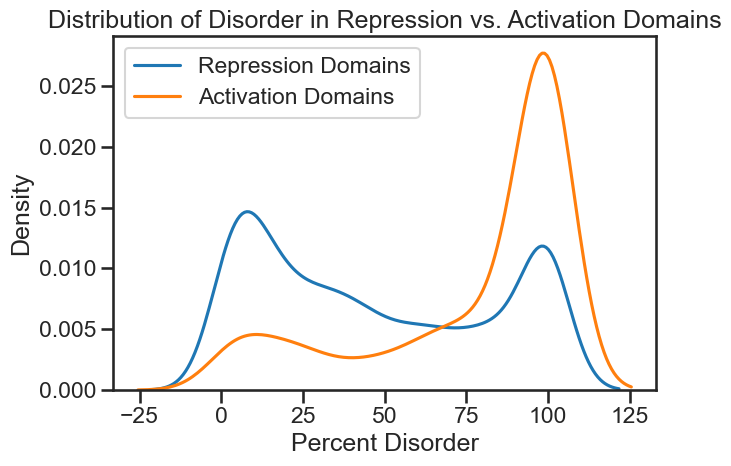

In [281]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

# Plot KDEs for both data sets
sns.kdeplot(
    data=full_tycko_soto_delrosso_rd_list, 
    x='Disorder_prediction', 
     
    label='Repression Domains'
)
sns.kdeplot(
    data=activation_domain_list, 
    x='Disorder_prediction',  
    label='Activation Domains'
)

# Label axes and add title
plt.xlabel('Percent Disorder')
plt.ylabel('Density')
plt.title('Distribution of Disorder in Repression vs. Activation Domains')

# Show legend and plot
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from collections import Counter
import seaborn as sns
activation_domain_list = pd.read_csv('known_ADs_considering_isoforms_and_canonical.csv')

In [274]:
activation_domain_list

,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,ProteinRegionSeq,Notes
0,ABRAXAS1,121,200,Q6UWZ7,[['Q6UWZ7']],ENST00000321945,Q6UWZ7,DelRosso et al.,CR,LQEHFSNQDLVFLLLTPSIITESCSTHRLEHSLYKPQKGLFHRVPL...,NaN
1,AEBP1,1088,1158,Q8IUX7,[['Q8IUX7']],NaN,Q8IUX7,Staller Activity Data,TF,EVVTEFGTEVEPEFGTKVEPEFETQLEPEFETQLEPEFEEEEEEEK...,NaN
2,AHCTF1,1445,1698,Q8WYP5,"[['Q8WYP5'], ['Q8WYP5']]",nan / nan,Q8WYP5 / Q8WYP5,"PMID: 11952839, Soto / transcriptionalactivity...",TF,IRANDNKSMADVLGDGGNSSLTISEGPIVSERRLNQEVALNLKEDH...,NaN
3,AHR,118,126,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL",TF,LLQALNGFV,NaN
4,AHR,266,268,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL",TF,FAI,NaN
...,...,...,...,...,...,...,...,...,...,...,...
739,ZSCAN20,262,341,P17040,"[['P17040', 'P17040-3']]",ENST00000361328,P17040,DelRosso et al.,TF,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,NaN
740,ZXDA,572,699,P98168,"[['P98168'], ['P98168']]",nan / nan,P98168 / P98168 / P98168,"PMID: 17493635, Soto / R4TA_regions.txt / acti...",TF,QDLLAQLEAANSLTPSSELTSQRQNDLSDAEIVSLFSDVPDSTSAA...,NaN
741,ZXDB,576,703,P98169,[['P98169']],NaN,P98169 / P98169,"R4TA_regions.txt / activation_regions.txt, GSL",TF,QDLLAQLEAANSLTPSSELTSQRQNDLSDAEIVSLFSDVPDSTSAA...,NaN
742,ZXDC,579,688,Q2QGD7,"[['Q2QGD7', 'Q2QGD7-2'], ['Q2QGD7', 'Q2QGD7-2']]",nan / nan,Q2QGD7 / Q2QGD7 / Q2QGD7,"PMID: 16600381, Soto / R4TA_regions.txt / acti...",TF,DSPLVLGTAATVLQQGSFSVDDVQTVSAGALGCLVALPMKNLSDDP...,NaN


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


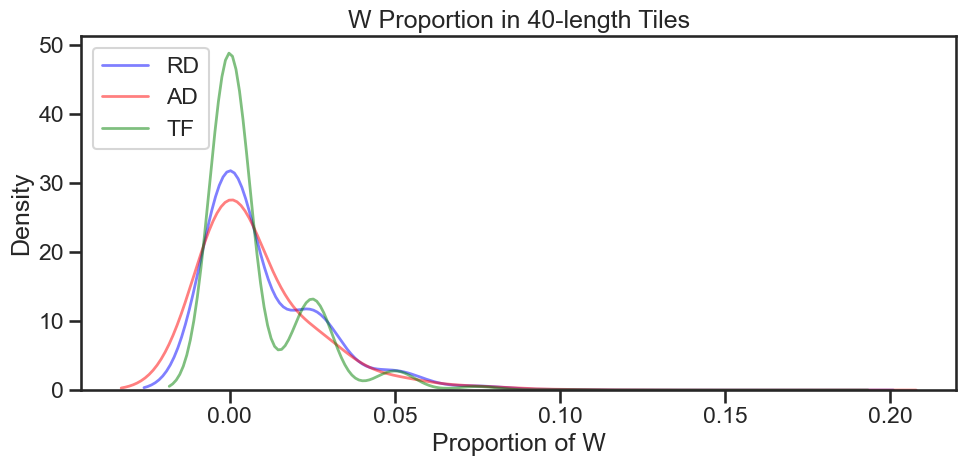

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


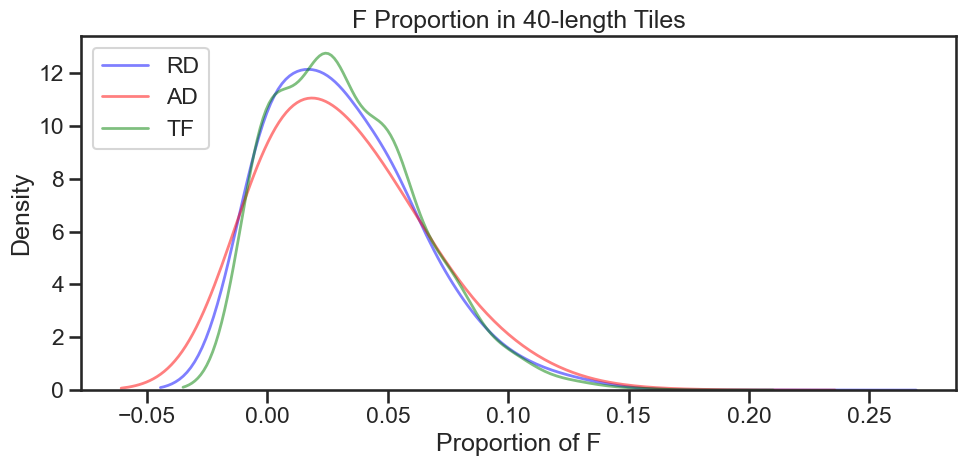

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


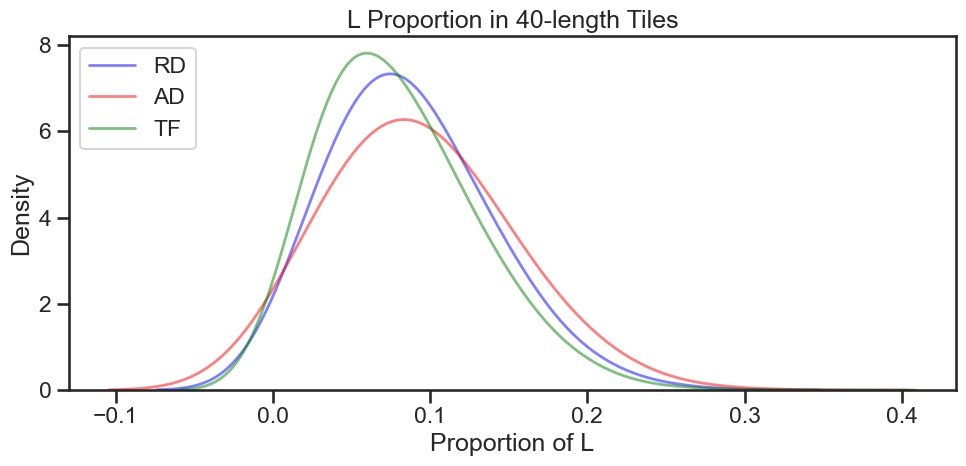

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


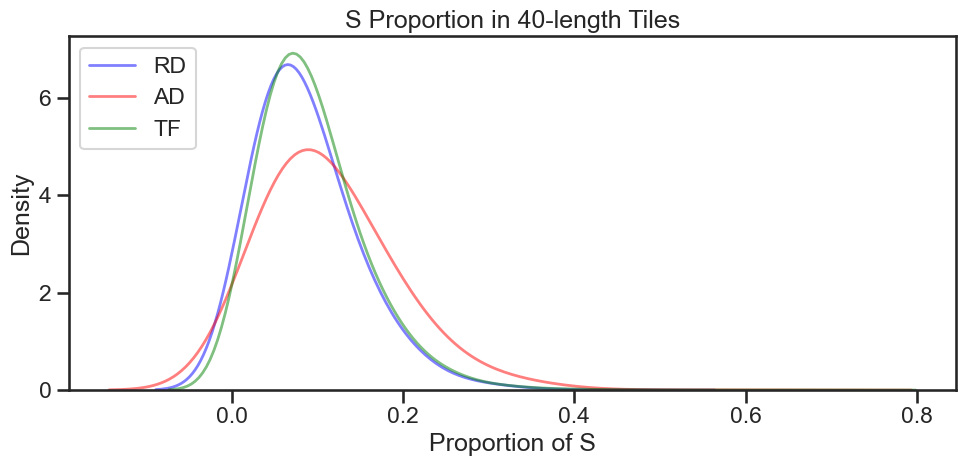

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


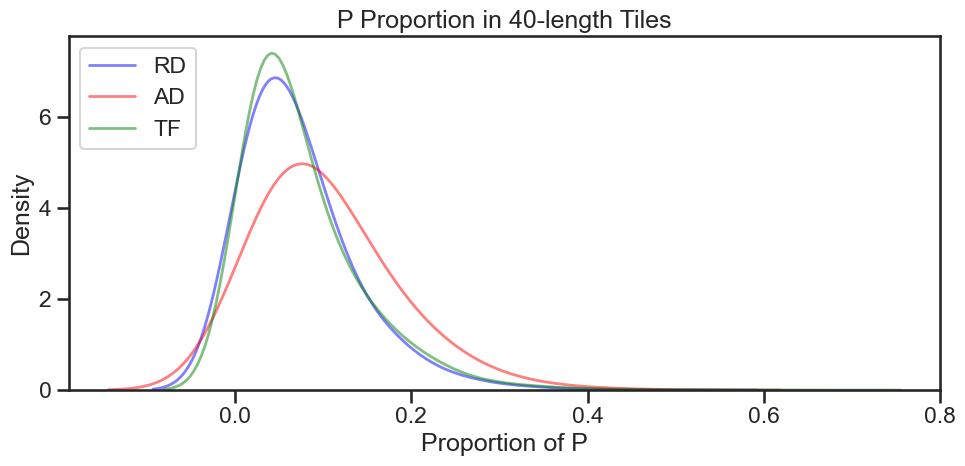

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


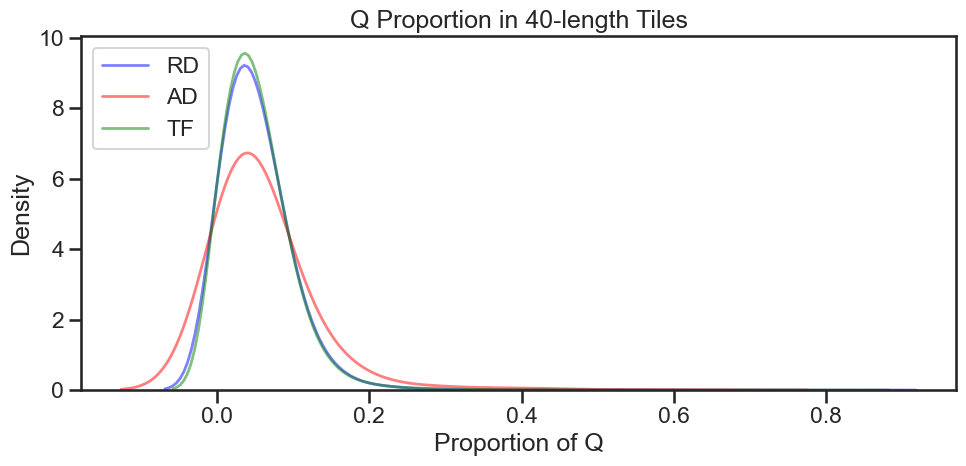

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


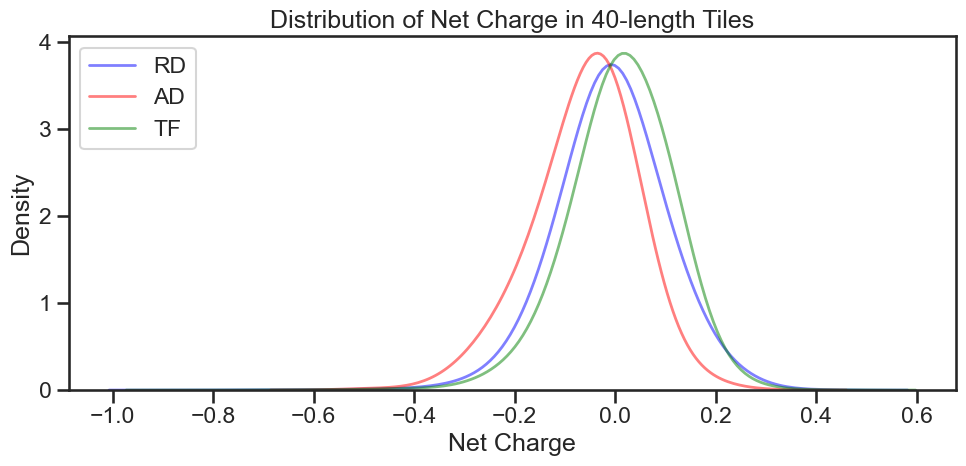

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


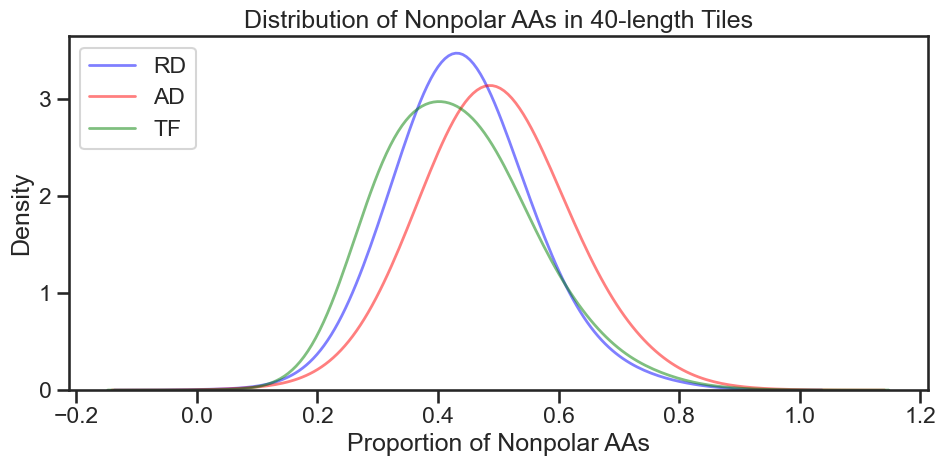

In [287]:
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from collections import Counter
import pandas as pd

# Define the amino acids of interest for your existing plots
amino_acids = ['W', 'F', 'L', 'S', 'P', 'Q']
tile_length = 40

# Define a set of nonpolar amino acids
nonpolar_aa = {'A','V','I','L','M','F','W','P', 'G'}

def calculate_tile_properties(tile):
    length = len(tile)
    aa_counts = Counter(tile)
    
    # Calculate the proportion of each amino acid in 'amino_acids'
    proportions = {aa: aa_counts.get(aa, 0) / length for aa in amino_acids}
    
    # Calculate net charge (R + K - D - E)
    net_charge = (aa_counts.get('R', 0) + aa_counts.get('K', 0) -
                  aa_counts.get('D', 0) - aa_counts.get('E', 0)) / length
    proportions['net_charge'] = net_charge
    
    # Calculate the proportion of nonpolar AAs in this tile
    nonpolar_count = sum(aa_counts.get(aa, 0) for aa in nonpolar_aa)
    proportions['nonpolar'] = nonpolar_count / length
    
    return proportions

def tile_and_calculate_properties(sequences, tile_length):
    tiled_properties = []
    for seq in sequences:
        # Generate non-overlapping tiles of length 'tile_length'
        for i in range(0, len(seq) - tile_length + 1, tile_length):
            tile = seq[i:i + tile_length]
            properties = calculate_tile_properties(tile)
            tiled_properties.append(properties)
    return pd.DataFrame(tiled_properties)

def load_sequences_from_fasta(fasta_file):
    return [str(record.seq) for record in SeqIO.parse(fasta_file, "fasta")]

# Paths to your RD and TF Lambert FASTA files
tf_fasta = 'LambertTFs.fasta'

# Load the sequences
rd_sequences = full_tycko_soto_delrosso_rd_list['Sequence'].tolist()
ad_sequences = activation_domain_list['ProteinRegionSeq'].tolist()
tf_sequences = load_sequences_from_fasta(tf_fasta)

# Calculate properties for RD, AD, and TF sequences
rd_properties = tile_and_calculate_properties(rd_sequences, tile_length)
ad_properties = tile_and_calculate_properties(ad_sequences, tile_length)
tf_properties = tile_and_calculate_properties(tf_sequences, tile_length)

# Now plot KDE distributions for each feature
# We'll include 'nonpolar' in the loop alongside your amino acids and 'net_charge'
for feature in amino_acids + ['net_charge', 'nonpolar']:
    plt.figure(figsize=(10, 5))
    
    sns.kdeplot(rd_properties[feature], color='blue', label='RD',
                alpha=0.5, linewidth=2, bw_adjust=3)
    sns.kdeplot(ad_properties[feature], color='red', label='AD',
                alpha=0.5, linewidth=2, bw_adjust=3)
    sns.kdeplot(tf_properties[feature], color='green', label='TF',
                alpha=0.5, linewidth=2, bw_adjust=3)
    
    sns.set_style('ticks')
    sns.set_context('talk')
    
    # Adjust labels and titles based on whether it's an AA, net charge, or nonpolar
    if feature == 'net_charge':
        plt.xlabel('Net Charge')
        plt.title('Distribution of Net Charge in 40-length Tiles')
    elif feature == 'nonpolar':
        plt.xlabel('Proportion of Nonpolar AAs')
        plt.title('Distribution of Nonpolar AAs in 40-length Tiles')
    else:
        plt.xlabel(f'Proportion of {feature}')
        plt.title(f'{feature} Proportion in 40-length Tiles')
    
    plt.ylabel('Density')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
